# STI Constituents Clustering (Current)

Cluster today's Straits Times Index (STI) constituents by **annualized return** and **volatility** using k-means.

This notebook is the live counterpart to the frozen 2020 COVID-era analysis in `STI Clustering.ipynb` (left unchanged).

**Defaults:** last ~3 years of daily prices, `StandardScaler`, elbow + silhouette for choosing `k`, fixed `random_state`.

In [1]:
from pathlib import Path
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
IMG_DIR = ROOT / "images" / "current"
IMG_DIR.mkdir(parents=True, exist_ok=True)

TICKERS_PATH = DATA_DIR / "sti_current.csv"
PRICES_PATH = DATA_DIR / "sti_prices_current.parquet"

REFRESH = False  # set True to re-download prices from Yahoo Finance
LOOKBACK_YEARS = 3
END = pd.Timestamp.today().normalize()
START = END - pd.DateOffset(years=LOOKBACK_YEARS)
RANDOM_STATE = 42
K_RANGE = range(2, 9)

print(f"Window: {START.date()} → {END.date()}")

Window: 2023-08-16 → 2026-08-16


## 1. Load current STI constituents

Tickers in `data/sti_current.csv` reflect the STI component list as of mid-2026 (Yahoo Finance / SGX symbols).

In [2]:
stidf = pd.read_csv(TICKERS_PATH)
assert len(stidf) == 30, f"Expected 30 STI names, found {len(stidf)}"
tickers = stidf["Symbol"].tolist()
name_map = dict(zip(stidf["Symbol"], stidf["Name"]))
sector_map = dict(zip(stidf["Symbol"], stidf["Sector"]))
stidf

,Symbol,Name,Sector
0,D05.SI,DBS Group Holdings,Financial Services
1,O39.SI,Oversea-Chinese Banking Corp,Financial Services
2,U11.SI,United Overseas Bank,Financial Services
3,Z74.SI,Singapore Telecommunications,Communication Services
4,S68.SI,Singapore Exchange,Financial Services
5,S63.SI,Singapore Technologies Engineering,Industrials
6,F34.SI,Wilmar International,Consumer Defensive
7,C6L.SI,Singapore Airlines,Industrials
8,BN4.SI,Keppel,Industrials
9,C38U.SI,CapitaLand Integrated Commercial Trust,Real Estate


## 2. Download (or load cached) adjusted close prices

In [3]:
if PRICES_PATH.exists() and not REFRESH:
    prices = pd.read_parquet(PRICES_PATH)
    print(f"Loaded cached prices from {PRICES_PATH}")
else:
    raw = yf.download(
        tickers,
        start=START.strftime("%Y-%m-%d"),
        end=(END + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        threads=True,
    )
    # yfinance returns MultiIndex columns when multiple tickers are requested
    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].rename(columns={"Close": tickers[0]})
    prices = prices.sort_index()
    prices.to_parquet(PRICES_PATH)
    print(f"Downloaded and cached prices → {PRICES_PATH}")

prices.head()

Downloaded and cached prices → /workspace/data/sti_prices_current.parquet


Ticker,5E2.SI,9CI.SI,A17U.SI,AJBU.SI,BN4.SI,BS6.SI,BUOU.SI,C09.SI,C38U.SI,C6L.SI,...,O39.SI,S58.SI,S63.SI,S68.SI,U11.SI,U14.SI,U96.SI,V03.SI,Y92.SI,Z74.SI
Date,,,,,,,,,,,,,,,,,,,,,
2023-08-16,2.625435,2.846007,2.267858,1.844847,5.979672,1.486183,0.974618,6.247269,1.640842,6.184587,...,10.682498,2.450707,3.514327,8.855799,24.563793,5.988525,5.168555,11.435007,0.496541,2.112302
2023-08-17,2.664621,2.846007,2.284720,1.827443,5.927675,1.494874,0.974618,6.247269,1.640842,6.149989,...,10.630684,2.460356,3.523432,8.764218,24.416134,5.997667,5.086514,11.375932,0.487906,2.103389
2023-08-18,2.664621,2.809520,2.284720,1.827443,5.789015,1.460109,0.958237,6.209747,1.640842,5.951044,...,10.596141,2.431410,3.505222,8.745904,24.259787,5.970239,4.904202,11.224030,0.487906,2.085563
2023-08-21,2.625435,2.773032,2.276289,1.810039,5.806349,1.442727,0.950047,6.190987,1.623570,5.968344,...,10.544325,2.421762,3.477622,8.645163,24.129498,5.869668,4.849509,11.181833,0.492223,2.085563
2023-08-22,2.645028,2.782154,2.267858,1.810039,5.806349,1.468801,0.950047,6.200367,1.614934,5.976994,...,10.578868,2.421762,3.486823,8.654321,24.181614,5.851383,4.803930,11.308419,0.505177,2.067738


In [4]:
# Drop names with too little history (< ~1 year of trading days)
min_obs = 252
valid_counts = prices.notna().sum()
keep = valid_counts[valid_counts >= min_obs].index.tolist()
dropped = sorted(set(prices.columns) - set(keep))
if dropped:
    print("Dropped (insufficient history):", [f"{t} ({name_map.get(t, t)})" for t in dropped])
else:
    print("All constituents have sufficient history.")

prices = prices[keep].dropna(how="all")
# Align to common trading calendar after dropping sparse columns
prices = prices.dropna(how="any")
print(f"Price panel: {prices.shape[0]} days × {prices.shape[1]} names")
prices.describe().T.head()

All constituents have sufficient history.
Price panel: 754 days × 30 names


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
5E2.SI,754.0,2.043969,0.303621,1.351903,1.890705,2.075014,2.230000,2.860549
9CI.SI,754.0,2.653678,0.170899,2.243967,2.530000,2.650000,2.770000,3.170000
A17U.SI,754.0,2.443255,0.140074,2.090813,2.333965,2.440875,2.547763,2.738639
AJBU.SI,754.0,1.962956,0.256155,1.446456,1.734237,2.031673,2.190764,2.330365
BN4.SI,754.0,7.688424,2.172771,5.302858,6.080054,6.408401,9.890236,12.928477


## 3. Return correlation (not price levels)

Correlating adjusted closes mixes shared trends. Pairwise **daily return** correlations are a cleaner co-movement signal.

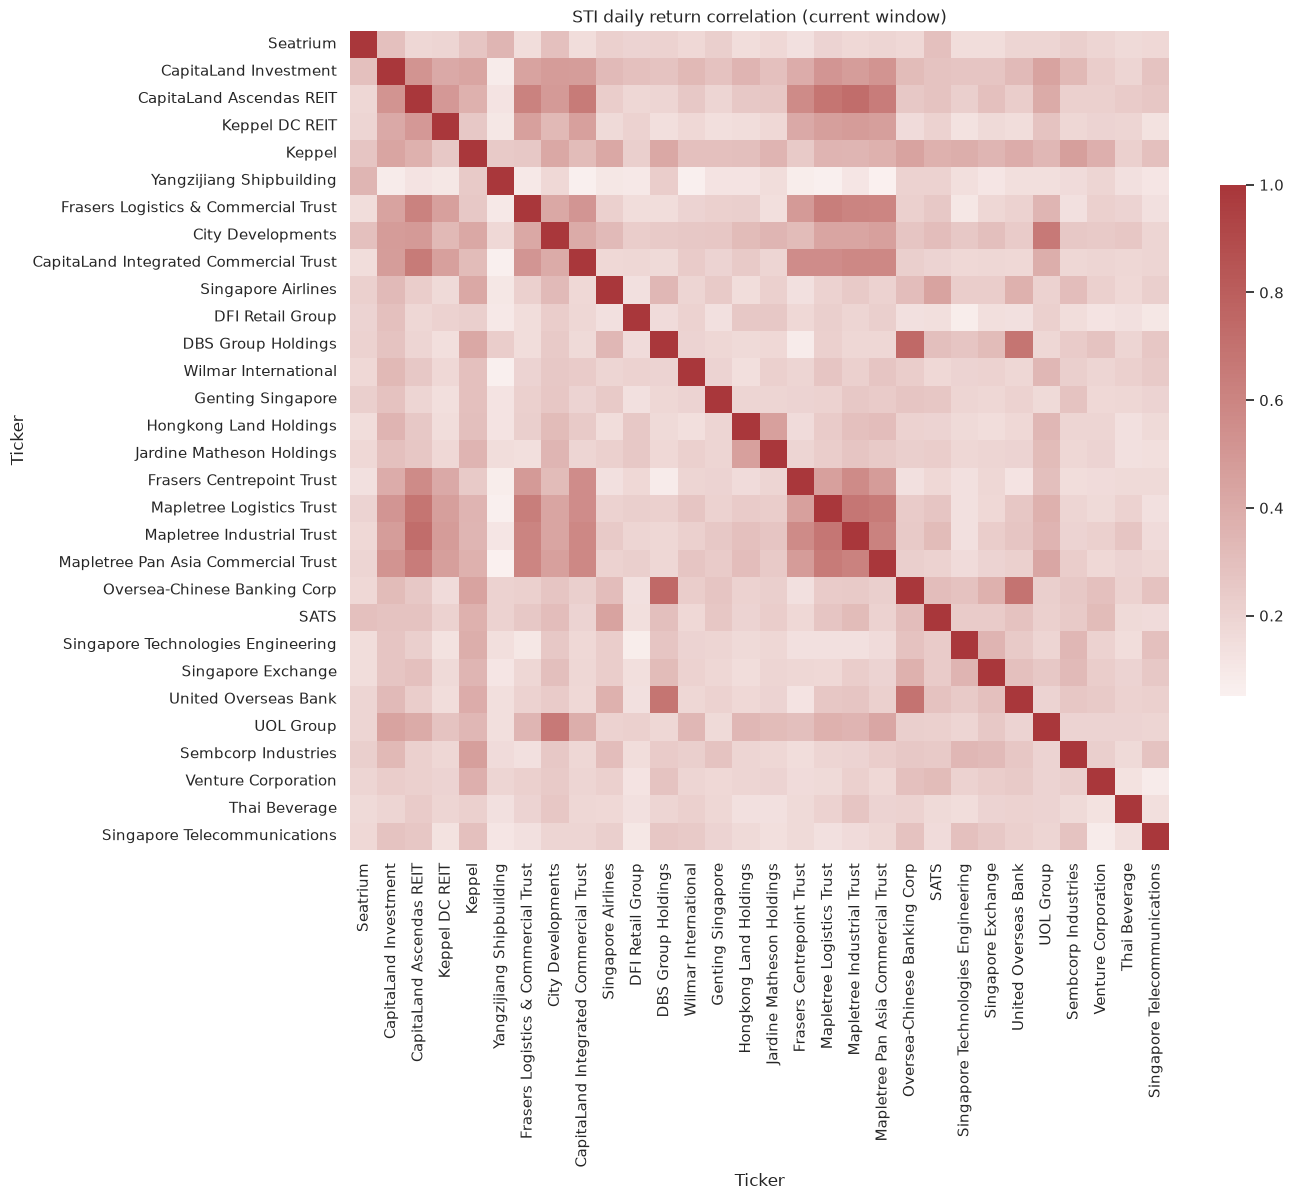

In [5]:
returns = prices.pct_change().dropna(how="all")
corr = returns.corr()

corr_named = corr.rename(index=name_map, columns=name_map)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_named,
    cmap="vlag",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.6},
    ax=ax,
)
ax.set_title("STI daily return correlation (current window)")
plt.tight_layout()
fig.savefig(IMG_DIR / "return_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Features: annualized return and volatility

In [6]:
avg_returns = returns.mean() * 252
vol = returns.std() * sqrt(252)

features = pd.DataFrame({
    "Avg_Return": avg_returns,
    "Volatility": vol,
})
features["Name"] = features.index.map(name_map)
features["Sector"] = features.index.map(sector_map)
features = features[["Name", "Sector", "Avg_Return", "Volatility"]].sort_values("Avg_Return", ascending=False)
features

,Name,Sector,Avg_Return,Volatility
Ticker,,,,
BS6.SI,Yangzijiang Shipbuilding,Industrials,0.444950,0.362565
S63.SI,Singapore Technologies Engineering,Industrials,0.408299,0.234501
D05.SI,DBS Group Holdings,Financial Services,0.380243,0.171704
H78.SI,Hongkong Land Holdings,Real Estate,0.379237,0.291247
O39.SI,Oversea-Chinese Banking Corp,Financial Services,0.378084,0.160523
S68.SI,Singapore Exchange,Financial Services,0.370424,0.198839
Z74.SI,Singapore Telecommunications,Communication Services,0.269644,0.200778
D01.SI,DFI Retail Group,Consumer Defensive,0.269386,0.330120
S58.SI,SATS,Industrials,0.245206,0.237201


## 5. Standardize features

Return and volatility are already scale-free percentages, so `StandardScaler` (z-scores) is a better default for k-means than min–max scaling of price levels.

In [7]:
feature_cols = ["Avg_Return", "Volatility"]
X_raw = features[feature_cols].to_numpy()
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

norm_df = pd.DataFrame(X, columns=["Z_Avg_Return", "Z_Volatility"], index=features.index)
norm_df["Name"] = features["Name"]
norm_df.head()

,Z_Avg_Return,Z_Volatility,Name
Ticker,,,
BS6.SI,1.972716,2.490726,Yangzijiang Shipbuilding
S63.SI,1.721002,0.271899,Singapore Technologies Engineering
D05.SI,1.528315,-0.816102,DBS Group Holdings
H78.SI,1.521406,1.255073,Hongkong Land Holdings
O39.SI,1.513491,-1.009826,Oversea-Chinese Banking Corp


## 6. Choose k with elbow + silhouette

With only ~30 names and two features, large `k` mostly isolates outliers. We search `k = 2…8` and prefer the silhouette maximum, using the elbow as a sanity check.

 k   inertia  silhouette
 2 34.043888    0.403469
 3 19.369969    0.442244
 4 14.794269    0.447126
 5 10.531741    0.383180
 6  7.676662    0.386393
 7  6.324780    0.379566
 8  5.199911    0.365352

Selected k = 4 (max silhouette)


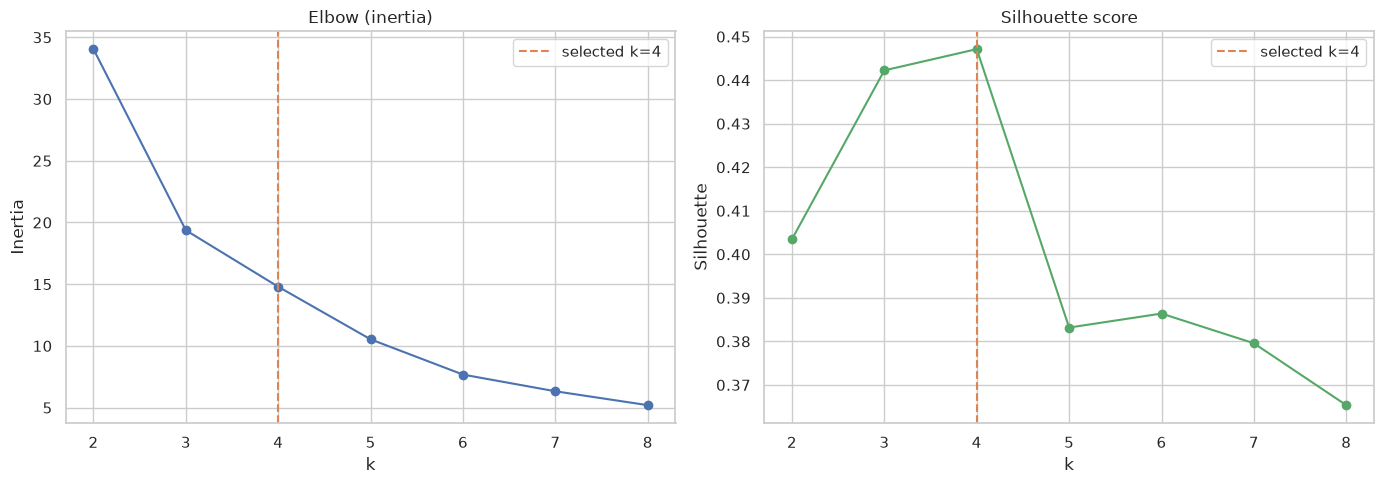

In [8]:
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels_k))

k_scores = pd.DataFrame({"k": list(K_RANGE), "inertia": inertias, "silhouette": silhouettes})
best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])
print(k_scores.to_string(index=False))
print(f"\nSelected k = {best_k} (max silhouette)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_scores["k"], k_scores["inertia"], marker="o")
axes[0].set_title("Elbow (inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].axvline(best_k, color="C1", ls="--", label=f"selected k={best_k}")
axes[0].legend()

axes[1].plot(k_scores["k"], k_scores["silhouette"], marker="o", color="C2")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].axvline(best_k, color="C1", ls="--", label=f"selected k={best_k}")
axes[1].legend()

plt.tight_layout()
fig.savefig(IMG_DIR / "k_selection.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Fit final k-means and inspect clusters

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10, max_iter=1000)
labels = kmeans.fit_predict(X)

result = features.copy()
result["Cluster"] = labels
result = result.sort_values(["Cluster", "Avg_Return"], ascending=[True, False])

summary = (
    result.groupby("Cluster")
    .agg(
        n=("Name", "size"),
        mean_return=("Avg_Return", "mean"),
        mean_vol=("Volatility", "mean"),
        sectors=("Sector", lambda s: ", ".join(sorted(s.value_counts().index[:3]))),
    )
    .round(3)
)
print("Cluster summary")
display(summary)
print("\nAssignments")
display(result)

Cluster summary


,n,mean_return,mean_vol,sectors
Cluster,,,,
0,18,0.065,0.195,"Consumer Defensive, Financial Services, Real E..."
1,7,0.326,0.202,"Communication Services, Financial Services, In..."
2,1,0.001,0.372,Energy
3,4,0.321,0.317,"Consumer Defensive, Industrials, Real Estate"



Assignments


,Name,Sector,Avg_Return,Volatility,Cluster
Ticker,,,,,
U11.SI,United Overseas Bank,Financial Services,0.190434,0.158057,0
U14.SI,UOL Group,Real Estate,0.172008,0.225754,0
V03.SI,Venture Corporation,Technology,0.153088,0.211599,0
C38U.SI,CapitaLand Integrated Commercial Trust,Real Estate,0.144939,0.164570,0
C09.SI,City Developments,Real Estate,0.113243,0.226276,0
AJBU.SI,Keppel DC REIT,Real Estate,0.085030,0.228130,0
F34.SI,Wilmar International,Consumer Defensive,0.082477,0.198961,0
U96.SI,Sembcorp Industries,Utilities,0.071811,0.249782,0
C6L.SI,Singapore Airlines,Industrials,0.058466,0.169887,0


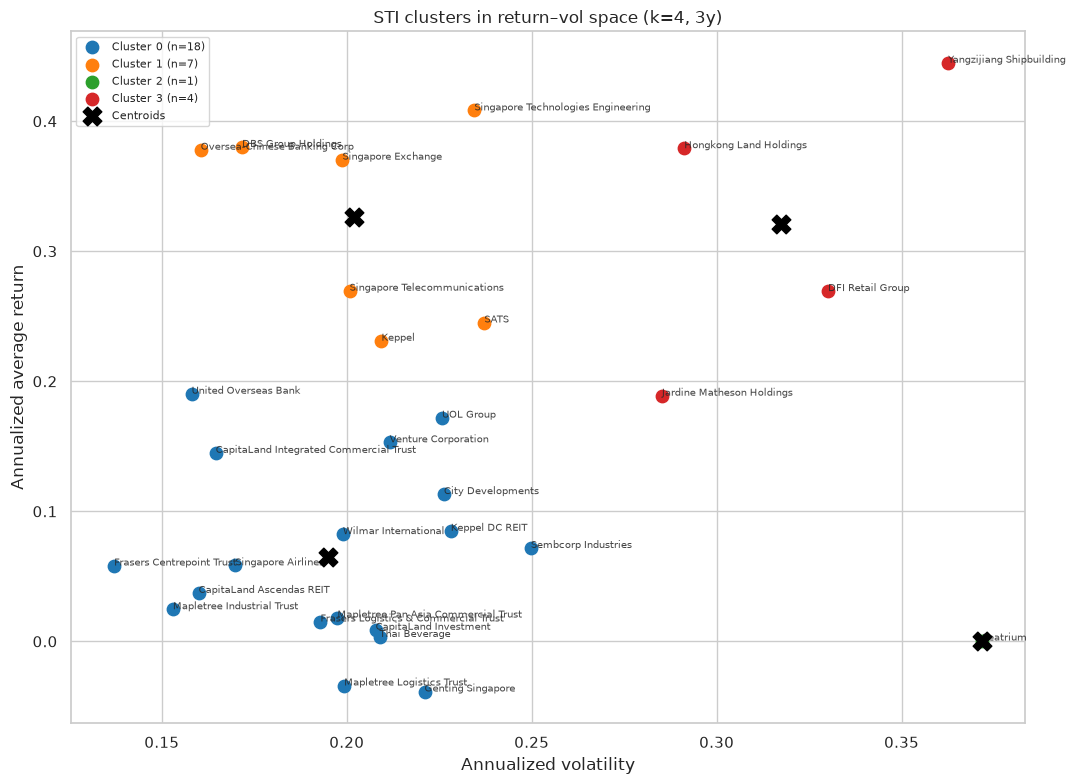

In [10]:
fig, ax = plt.subplots(figsize=(11, 8))
palette = sns.color_palette("tab10", n_colors=best_k)

for cluster_id, grp in result.groupby("Cluster"):
    ax.scatter(
        grp["Volatility"],
        grp["Avg_Return"],
        s=80,
        color=palette[cluster_id],
        label=f"Cluster {cluster_id} (n={len(grp)})",
        zorder=3,
    )
    for _, row in grp.iterrows():
        ax.annotate(row["Name"], (row["Volatility"], row["Avg_Return"]), fontsize=7, alpha=0.85)

centers_raw = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(
    centers_raw[:, 1],
    centers_raw[:, 0],
    marker="X",
    s=180,
    c="black",
    label="Centroids",
    zorder=4,
)

ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized average return")
ax.set_title(f"STI clusters in return–vol space (k={best_k}, {LOOKBACK_YEARS}y)")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
fig.savefig(IMG_DIR / "clusters_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Takeaways

- Baskets here group names with **similar realized return/vol profiles**, not industry labels alone — though sector peers (banks, REITs) often land nearby.
- For diversification ideas, prefer picking across clusters rather than within one tight cluster.
- Re-run with `REFRESH = True` after STI membership changes, or shorten/lengthen `LOOKBACK_YEARS`.
- This is exploratory analysis, not investment advice.

In [11]:
# Persist labeled results for README / reuse
out_path = DATA_DIR / "sti_clusters_current.csv"
result.to_csv(out_path)
print(f"Wrote {out_path}")
print(f"Figures in {IMG_DIR}")

Wrote /workspace/data/sti_clusters_current.csv
Figures in /workspace/images/current
